In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep  
#import os
#import joblib
#from xgboost import XGBClassifier
#from sklearn.model_selection import train_test_split, GridSearchCV
#from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix)

In [2]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/Non_Ressonant_data/Signal_MC.root"
bg_path = "/home/tandrade/Flavour_Anomalies/Data/Non_Ressonant_data/Background_Data.root"
tree_name = "tree_ML"

In [3]:
features = [
    'BToTrkTrkMuMu_l_xy_sig_good', 'BToTrkTrkMuMu_dca_sig_good',
    'BToTrkTrkMuMu_trk1_dca_sig_good', 'BToTrkTrkMuMu_trk2_dca_sig_good',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good', 'BToTrkTrkMuMu_fit_pt_good',
    'BToTrkTrkMuMu_fit_cos2D_good', 'BToTrkTrkMuMu_svprob_good'
]

In [4]:
signal_file = uproot.open(signal_path)[tree_name]
background_file = uproot.open(bg_path)[tree_name]

In [5]:
signal_ak = signal_file.arrays(library="ak")
background_ak = background_file.arrays(library="ak")

In [6]:
signal_df = ak.to_dataframe(signal_ak)
background_df = ak.to_dataframe(background_ak)

In [7]:
signal_df["label"] = 1
background_df["label"] = 0

In [8]:
df = pd.concat([signal_df, background_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [9]:
df

,MuMu_mass_idx_good,MuMu_pt_idx_good,MuMu_eta_idx_good,MuMu_phi_idx_good,MuMu_svprob_idx_good,MuMu_l_xy_idx_good,MuMu_l_xy_unc_idx_good,MuMu_fit_cos2D_idx_good,Muon_softMvaRun3_l1_idx_good,Muon_softMvaRun3_l2_idx_good,...,BToTrkTrkMuMu_fit_eta_good,BToTrkTrkMuMu_fit_phi_good,BToTrkTrkMuMu_l_xy_sig_good,BToTrkTrkMuMu_dca_sig_good,BToTrkTrkMuMu_trk1_dca_sig_good,BToTrkTrkMuMu_trk2_dca_sig_good,BToTrkTrkMuMu_cos_theta_l_good,BToTrkTrkMuMu_cos_theta_k_good,BToTrkTrkMuMu_phi_angle_good,label
0,1.579102,14.536581,0.761108,-2.253906,0.884835,0.827042,0.011070,0.992000,0.851562,0.835938,...,0.687519,-2.384745,191.790222,-1.048364,-61.096252,-60.423653,0.070150,-0.561278,2.397156,1
1,1.624023,15.104328,0.123108,-1.896484,0.436957,0.095239,0.023158,0.999968,0.906250,0.890625,...,0.244182,-1.944523,0.332639,-0.468762,-0.107162,0.822626,0.594444,0.563791,2.639388,0
2,2.134766,13.149431,0.198425,-2.291016,0.987729,0.045511,0.006214,0.994295,0.765625,0.804688,...,0.194562,-2.365375,7.849549,2.299866,-2.241618,-2.035025,0.177258,-0.919054,1.030790,0
3,2.117188,10.378967,1.284912,1.627197,0.974288,0.109676,0.013712,0.999094,0.921875,0.867188,...,1.167235,1.604614,16.728426,2.525518,0.532034,-2.210678,-0.441967,-0.296648,-0.845617,1
4,2.691406,9.325996,0.456421,-1.765625,0.903480,0.034220,0.010254,0.999252,0.898438,0.898438,...,0.621371,-1.792961,2.169698,-0.292014,0.452427,0.610683,-0.555283,0.364787,1.191720,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366685,2.455078,12.826670,-1.100830,-1.255127,0.884384,0.037023,0.009054,0.998462,0.890625,0.750000,...,-1.114601,-1.152086,3.922139,-1.459914,-0.086103,0.557876,-0.040020,0.439290,-2.915975,0
366686,2.121094,9.015355,-0.570190,-1.587891,0.364804,0.047247,0.007676,0.996313,0.796875,0.867188,...,-0.796209,-1.633011,5.347301,-2.329762,-1.054547,1.388576,0.051394,0.683287,-0.319231,0
366687,2.025391,8.878573,1.515137,2.652344,0.766066,0.179005,0.006499,0.995672,0.820312,0.914062,...,1.359854,2.561970,51.771122,0.120906,-10.724353,-11.603487,0.383434,-0.359236,0.659832,1
366688,4.378906,23.491968,0.617065,-0.329041,0.828238,0.552712,0.003582,0.999947,0.812500,0.914062,...,0.615492,-0.340569,157.891357,-0.533429,-24.333801,12.897897,0.769175,0.887853,1.885299,1


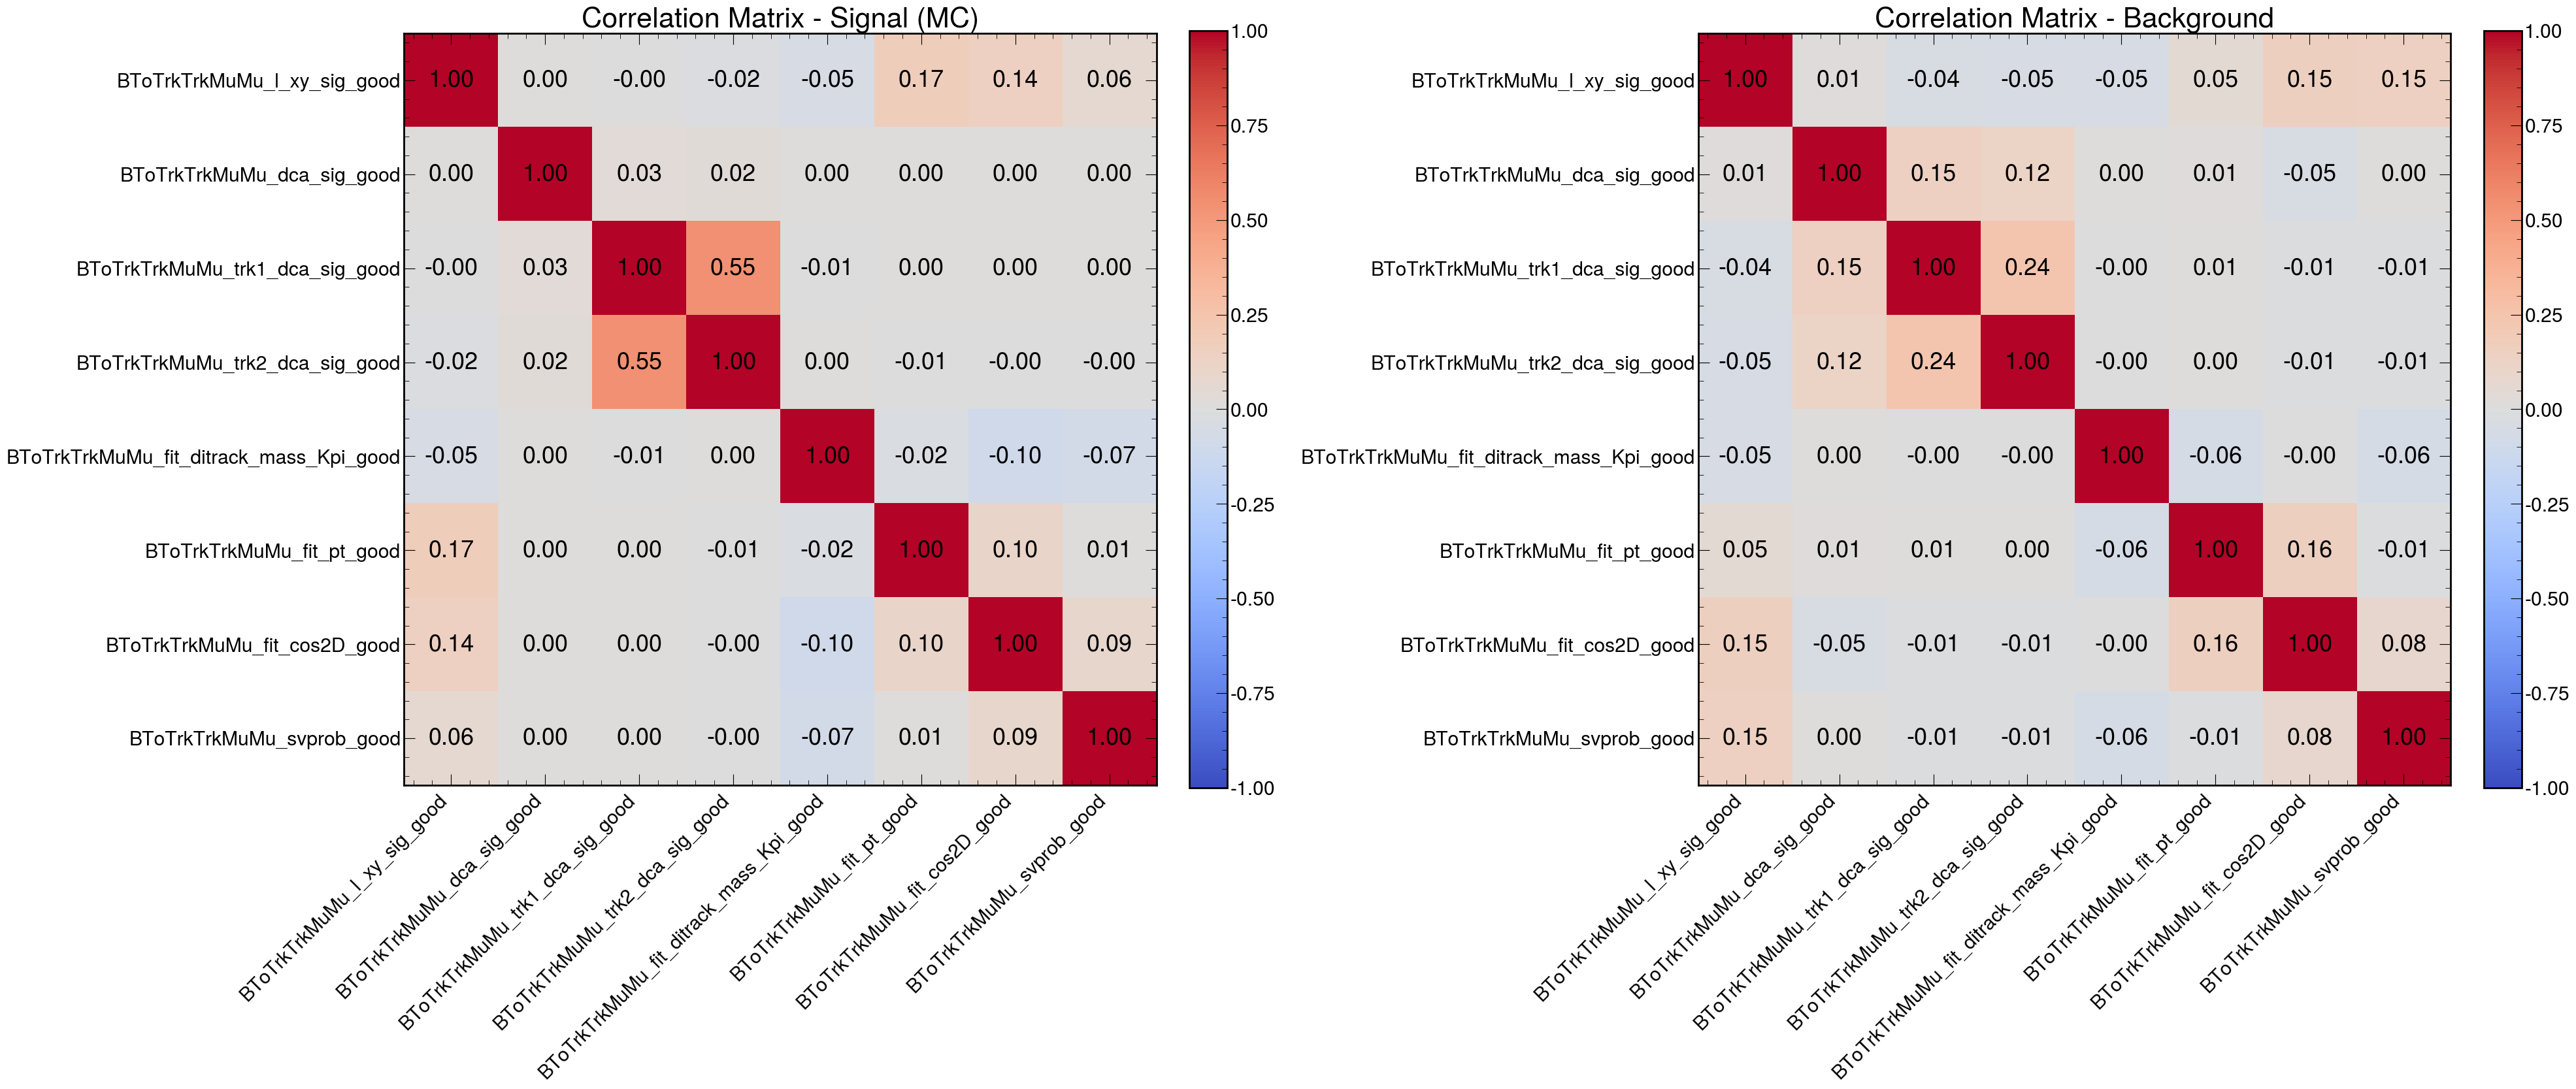

In [11]:
plt.style.use(hep.style.CMS)
plt.figure(figsize=(40, 25))

ax1 = plt.subplot(1,2,1)
corr_signal = signal_df[features].corr()
im1 = plt.imshow(corr_signal, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im1, fraction=0.046, pad=0.04)
plt.title("Correlation Matrix - Signal (MC)")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features)), labels=features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_signal.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax2 = plt.subplot(1,2,2)
corr_background = background_df[features].corr()
im2 = plt.imshow(corr_background, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im2, fraction=0.046, pad=0.04)
plt.title("Correlation Matrix - Background")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(features)), labels=features)
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(j, i, f"{corr_background.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.tight_layout()
plt.savefig("Plots/correlation_matrices.png", dpi=100, bbox_inches='tight')
plt.show()

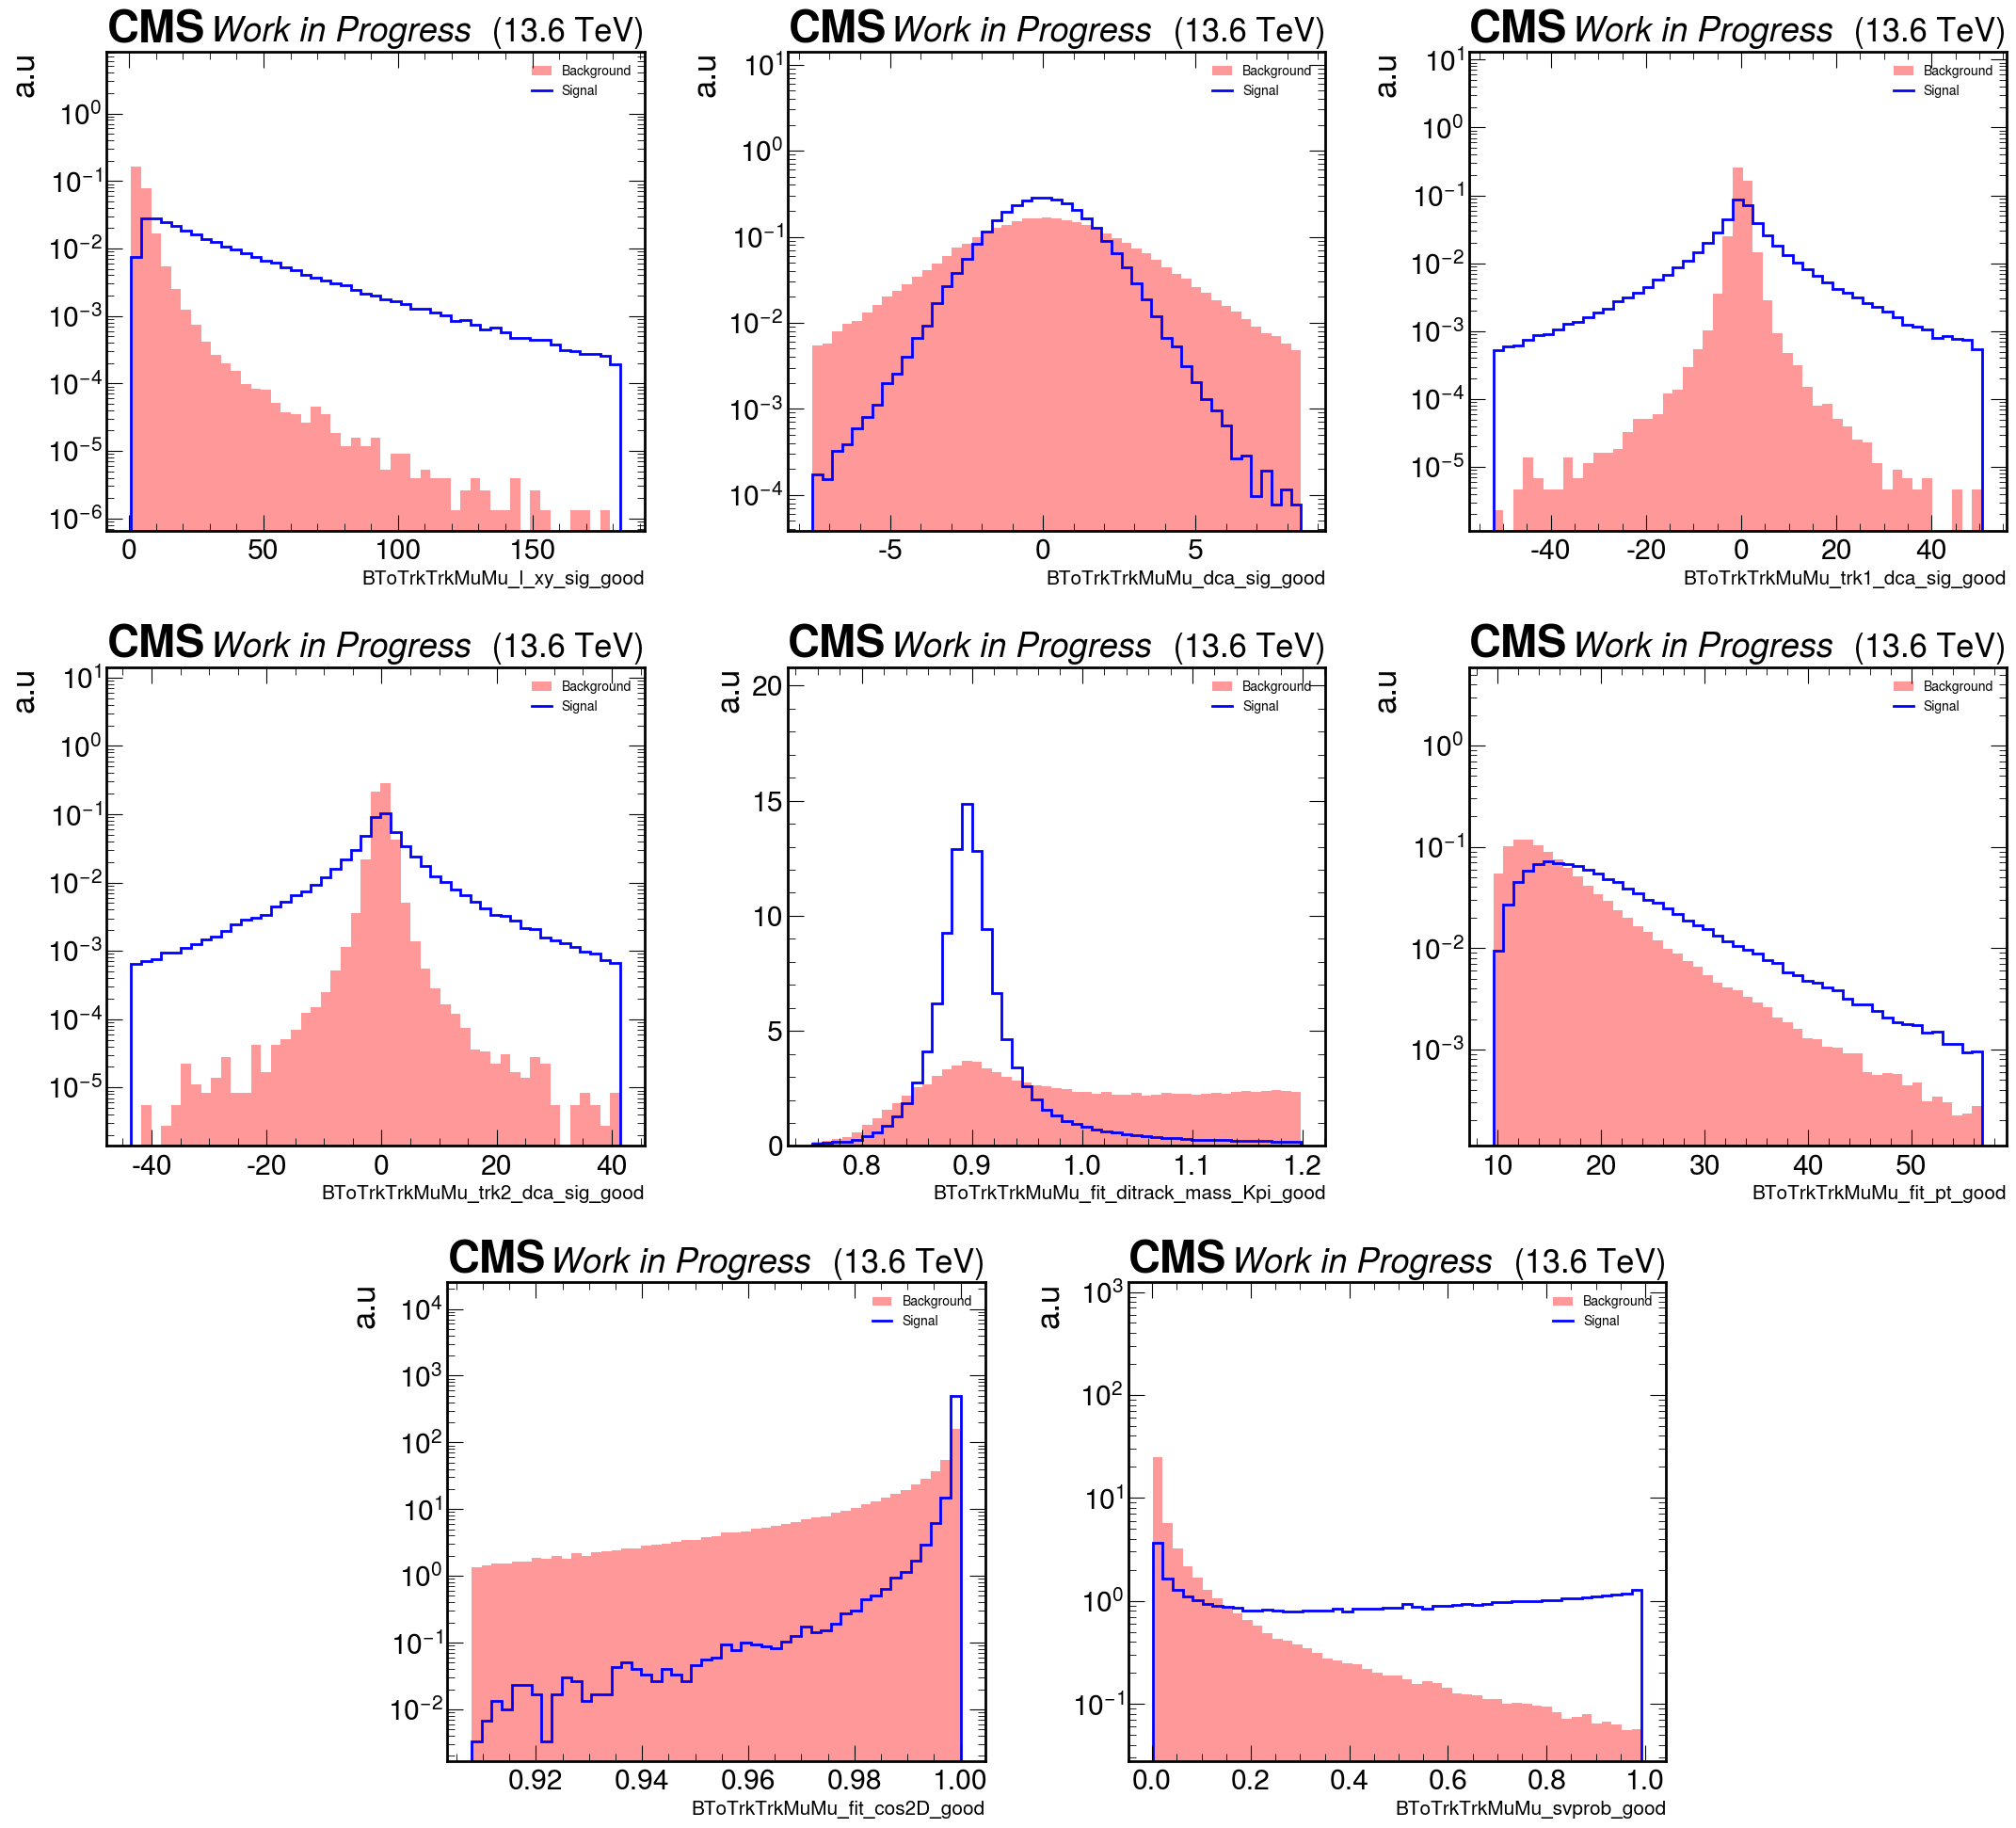

In [12]:
plt.style.use(hep.style.ROOT)

def plot_custom_grid(df, features, log_features=[]):

    fig = plt.figure(figsize=(22, 20))
    gs = fig.add_gridspec(3, 6)
    
    axes = []
    axes.append(fig.add_subplot(gs[0, 0:2])) # Colunas 0 e 1
    axes.append(fig.add_subplot(gs[0, 2:4])) # Colunas 2 e 3
    axes.append(fig.add_subplot(gs[0, 4:6])) # Colunas 4 e 5
    
    axes.append(fig.add_subplot(gs[1, 0:2]))
    axes.append(fig.add_subplot(gs[1, 2:4]))
    axes.append(fig.add_subplot(gs[1, 4:6]))
    
    axes.append(fig.add_subplot(gs[2, 1:3])) 
    axes.append(fig.add_subplot(gs[2, 3:5])) 
    
    for i, feature in enumerate(features):
        if i >= len(axes): break
        
        ax = axes[i]
        
        sig_data = df[df['label'] == 1][feature].dropna()
        bkg_data = df[df['label'] == 0][feature].dropna()
        
        if len(sig_data) == 0 or len(bkg_data) == 0: continue

        low = min(np.percentile(sig_data, 1), np.percentile(bkg_data, 1))
        high = max(np.percentile(sig_data, 99), np.percentile(bkg_data, 99))
        bins = np.linspace(low, high, 50)
        
        counts_bkg, _ = np.histogram(bkg_data, bins=bins, density=True)
        counts_sig, _ = np.histogram(sig_data, bins=bins, density=True)
        
        hep.histplot(counts_bkg, bins=bins, ax=ax, label='Background', color='red', alpha=0.4, histtype='fill')        
        hep.histplot(counts_sig, bins=bins, ax=ax, label='Signal', color='blue', linewidth=2, histtype='step')
        
        if feature in log_features:
            ax.set_yscale('log')
            all_counts = np.concatenate([counts_bkg, counts_sig])
            min_val = np.min(all_counts[all_counts > 0])
            ax.set_ylim(bottom=min_val * 0.5, top=np.max(all_counts) * 50)
            ylabel_text = "a.u"
        else:
            ylabel_text = "a.u"
            ax.set_ylim(top=np.max(np.concatenate([counts_bkg, counts_sig])) * 1.4)

        ax.set_xlabel(feature, fontsize=15)
        ax.set_ylabel(ylabel_text, fontsize=25)
        ax.legend(loc='best', fontsize=10)
        hep.cms.label(loc=0, ax=ax, data=True, com="13.6", label="Work in Progress")

    plt.tight_layout()
    plt.savefig("Plots/Overlay.png")
    plt.show()


features_para_log = [
    "BToTrkTrkMuMu_l_xy_sig_good",
    "BToTrkTrkMuMu_dca_sig_good",
    "BToTrkTrkMuMu_trk1_dca_sig_good",
    "BToTrkTrkMuMu_trk2_dca_sig_good",
    "BToTrkTrkMuMu_fit_pt_good",
    "BToTrkTrkMuMu_fit_cos2D_good",
    "BToTrkTrkMuMu_svprob_good"
]

plot_custom_grid(df, features, log_features=features_para_log)